# 05 — Baseline Training: Conv2D + ConvLSTM (RGB)
### SIBI Lip Reading — Dataset Gabungan (Angka + Alphabet + Kata)

In [22]:
# ── Cell 1: Import ──────────────────────────────────────────────────────────
import json, time, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, precision_score, recall_score
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {device}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')

PyTorch : 2.11.0+cu128
Device  : cuda
GPU     : NVIDIA GeForce RTX 5050 Laptop GPU
VRAM    : 8.09 GB


In [23]:
# ── Cell 2: Config ──────────────────────────────────────────────────────────
BASE_DIR     = Path('/home/wipra-ranum/Documents/Skripsi/LipReading')
PROJECT_ROOT = BASE_DIR / 'Lip_Reading_Gabungan'
RAW_LIPS     = PROJECT_ROOT / 'preprocessed' / 'dependent' / 'raw_lips'
MODELS_DIR   = PROJECT_ROOT / 'models'
RESULTS_DIR  = PROJECT_ROOT / 'results' / 'baseline_training'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

with open(PROJECT_ROOT / 'config.json') as f:
    cfg = json.load(f)

CLASSES      = cfg['data']['classes']
NUM_CLASSES  = len(CLASSES)
IDX_TO_CLASS = {i: c for i, c in enumerate(CLASSES)}
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

BATCH_SIZE   = 8
NUM_EPOCHS   = 100
LR           = 0.001
WEIGHT_DECAY = 1e-5
SEED         = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print(f'Data    : {RAW_LIPS}')
print(f'Classes : {NUM_CLASSES} kelas — {CLASSES}')
print(f'Epochs  : {NUM_EPOCHS} | Batch: {BATCH_SIZE} | LR: {LR}')

Data    : /home/wipra-ranum/Documents/Skripsi/LipReading/Lip_Reading_Gabungan/preprocessed/dependent/raw_lips
Classes : 18 kelas — ['1', '2', '3', '8', '9', '10', 'a', 'b', 'c', 'd', 'e', 'f', 'buku', 'dia', 'saya', 'keliling', 'kelompok', 'sekarang']
Epochs  : 100 | Batch: 8 | LR: 0.001


---
## Dataset & DataLoader

In [ ]:
# ── Cell 3: Dataset ─────────────────────────────────────────────────────────
class LipDataset(Dataset):
    """Load .npy lip sequences [T,H,W,C] → tensor [C,T,H,W]."""

    def __init__(self, root, classes, split, transform=None):
        self.samples, self.labels = [], []
        self.transform = transform
        for idx, cls in enumerate(classes):
            d = Path(root) / split / cls
            if not d.exists():
                print(f'  Warning: {d} tidak ditemukan')
                continue
            for f in sorted(d.glob('*.npy')):
                self.samples.append(f)
                self.labels.append(idx)
        print(f'  {split:5s}: {len(self.samples)} samples')

    def __len__(self): return len(self.samples)

    def __getitem__(self, i):
        seq = np.load(self.samples[i]).astype(np.float32) / 255.0  # [T,H,W,C]
        seq = torch.from_numpy(seq.transpose(3, 0, 1, 2))           # [C,T,H,W]
        if self.transform: 
            seq = self.transform(seq)
        return seq, torch.tensor(self.labels[i], dtype=torch.long)

In [25]:
# ── Cell 4: DataLoader ──────────────────────────────────────────────────────
print('Loading datasets...')
train_ds = LipDataset(RAW_LIPS, CLASSES, 'train')
val_ds   = LipDataset(RAW_LIPS, CLASSES, 'val')
test_ds  = LipDataset(RAW_LIPS, CLASSES, 'test')

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f'\nTrain : {len(train_ds)} samples ({len(train_loader)} batches)')
print(f'Val   : {len(val_ds)} samples ({len(val_loader)} batches)')
print(f'Test  : {len(test_ds)} samples ({len(test_loader)} batches)')

x, y = next(iter(train_loader))
print(f'\nBatch shape  : {x.shape}')
print(f'Value range  : [{x.min():.3f}, {x.max():.3f}]')
print(f'Label sample : {[IDX_TO_CLASS[l.item()] for l in y]}')

Loading datasets...
  train: 2520 samples
  val  : 720 samples
  test : 360 samples

Train : 2520 samples (315 batches)
Val   : 720 samples (90 batches)
Test  : 360 samples (45 batches)

Batch shape  : torch.Size([8, 3, 30, 96, 96])
Value range  : [0.000, 1.000]
Label sample : ['9', 'd', 'a', 'keliling', '2', 'f', '10', '10']


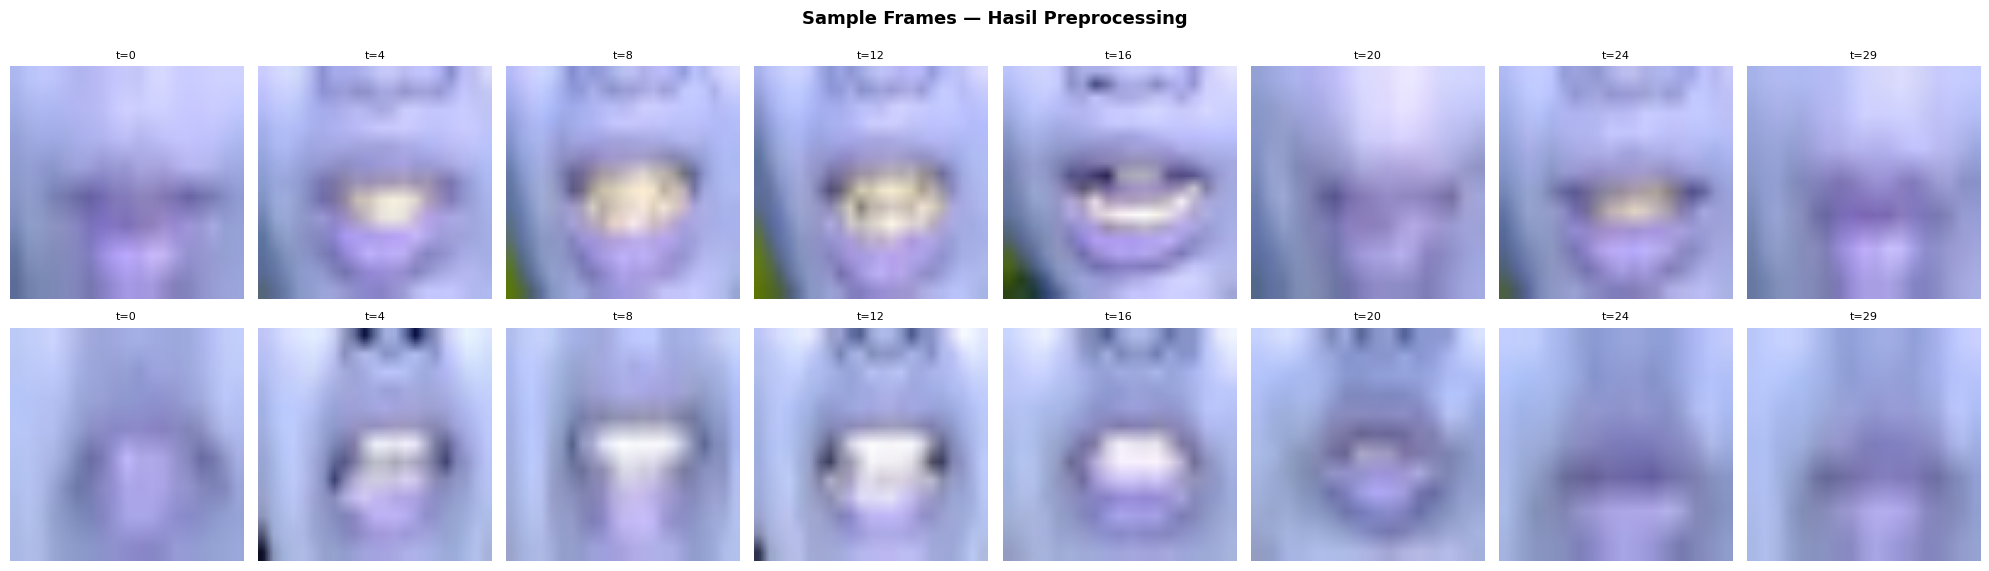

In [26]:
# ── Cell 5: Visualisasi sampel ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 8, figsize=(20, 6))
fig.suptitle('Sample Frames — Hasil Preprocessing', fontsize=13, fontweight='bold')
for row in range(2):
    seq, lbl = train_ds[random.randint(0, len(train_ds)-1)]
    for col, t in enumerate(np.linspace(0, 29, 8, dtype=int)):
        frame = seq[:, t].permute(1, 2, 0).numpy()
        axes[row][col].imshow(frame)
        axes[row][col].set_title(f't={t}', fontsize=8)
        axes[row][col].axis('off')
    axes[row][0].set_ylabel(f"Kelas: {IDX_TO_CLASS[lbl.item()]}", fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'sample_frames.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Arsitektur Model: Conv2D + ConvLSTM

In [27]:
# ── Cell 6: ConvLSTM Cell ───────────────────────────────────────────────────
class ConvLSTMCell(nn.Module):
    """
    ConvLSTM: menggantikan matrix multiplication LSTM dengan Conv2D.
    Informasi spasial tetap terjaga di dalam hidden state.
    Ref: Shi et al. (2015), NeurIPS.
    """
    def __init__(self, in_ch, h_ch, k=3):
        super().__init__()
        self.h_ch = h_ch
        self.conv = nn.Conv2d(in_ch + h_ch, 4 * h_ch, k, padding=k // 2)

    def forward(self, x, state):
        h, c = state
        i, f, o, g = torch.split(self.conv(torch.cat([x, h], dim=1)), self.h_ch, dim=1)
        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        o = torch.sigmoid(o)
        g = torch.tanh(g)
        c_next = f * c + i * g
        h_next = o * torch.tanh(c_next)
        return h_next, c_next

    def init_hidden(self, B, H, W, dev):
        return (torch.zeros(B, self.h_ch, H, W, device=dev),
                torch.zeros(B, self.h_ch, H, W, device=dev))

In [28]:
# ── Cell 7: Model utama ──────────────────────────────────────────────────────
class BaselineModel(nn.Module):
    """
    Conv2D per-frame (spatial) → ConvLSTM (temporal) → Classifier.
    Input : [B, 3, T, H, W]  =  [B, 3, 30, 96, 96]
    Output: [B, num_classes]
    """
    def __init__(self, num_classes=10, dropout=0.5):
        super().__init__()

        def cblock(ic, oc):
            return nn.Sequential(
                nn.Conv2d(ic, oc, 3, padding=1),
                nn.BatchNorm2d(oc),
                nn.ReLU(),
                nn.MaxPool2d(2)
            )

        # Spatial CNN: 96 → 48 → 24 → 12
        self.cnn   = nn.Sequential(cblock(3, 32), cblock(32, 64), cblock(64, 128))
        self.lstm1 = ConvLSTMCell(128, 128)
        self.lstm2 = ConvLSTMCell(128, 64)
        self.head  = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):                               # x: [B, C, T, H, W]
        B, C, T, H, W = x.shape
        x = x.permute(0, 2, 1, 3, 4).reshape(B*T, C, H, W)
        x = self.cnn(x)                                 # [B*T, 128, 12, 12]
        _, c, h, w = x.shape
        x = x.view(B, T, c, h, w)

        h1, c1 = self.lstm1.init_hidden(B, h, w, x.device)
        h2, c2 = self.lstm2.init_hidden(B, h, w, x.device)
        for t in range(T):
            h1, c1 = self.lstm1(x[:, t], (h1, c1))
            h2, c2 = self.lstm2(h1, (h2, c2))

        out = h2.mean(dim=[-2, -1])                     # Global Avg Pool → [B, 64]
        return self.head(out)

In [29]:
# ── Cell 8: Init model + ukur efisiensi ────────────────────────────────────
model = BaselineModel(num_classes=NUM_CLASSES, dropout=0.5).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
model_size_mb    = total_params * 4 / 1e6

# Hitung GFLOPs secara manual (forward pass profiling)
dummy = torch.randn(1, 3, 30, 96, 96).to(device)

# Gunakan thop jika ada, fallback ke estimasi manual
try:
    from thop import profile, clever_format
    macs, _ = profile(model, inputs=(dummy,), verbose=False)
    gflops  = macs * 2 / 1e9
    gflops_str = f'{gflops:.3f} GFLOPs'
except ImportError:
    # Estimasi GFLOPs dari parameter count (pendekatan kasar)
    gflops = total_params * 30 * 2 / 1e9  # T=30 timestep
    gflops_str = f'~{gflops:.3f} GFLOPs (estimasi)'

# Ukur inference time
model.eval()
with torch.no_grad():
    # Warmup
    for _ in range(5):
        _ = model(dummy)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(50):
        _ = model(dummy)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    infer_ms = (time.time() - t0) / 50 * 1000
model.train()

# Forward pass check
with torch.no_grad():
    out_test = model(torch.randn(2, 3, 30, 96, 96).to(device))

print('=' * 55)
print('  MODEL SUMMARY')
print('=' * 55)
print(f'  Arsitektur       : Conv2D + ConvLSTM')
print(f'  Total params     : {total_params:,}')
print(f'  Trainable params : {trainable_params:,}')
print(f'  Model size       : {model_size_mb:.2f} MB (float32)')
print(f'  GFLOPs           : {gflops_str}')
print(f'  Inference time   : {infer_ms:.2f} ms/sample (GPU)')
print(f'  Input shape      : [B, 3, 30, 96, 96]')
print(f'  Output shape     : {out_test.shape}  (expected [2, {NUM_CLASSES}])')
print('=' * 55)

  MODEL SUMMARY
  Arsitektur       : Conv2D + ConvLSTM
  Total params     : 1,737,746
  Trainable params : 1,737,746
  Model size       : 6.95 MB (float32)
  GFLOPs           : ~0.104 GFLOPs (estimasi)
  Inference time   : 8.00 ms/sample (GPU)
  Input shape      : [B, 3, 30, 96, 96]
  Output shape     : torch.Size([2, 18])  (expected [2, 18])


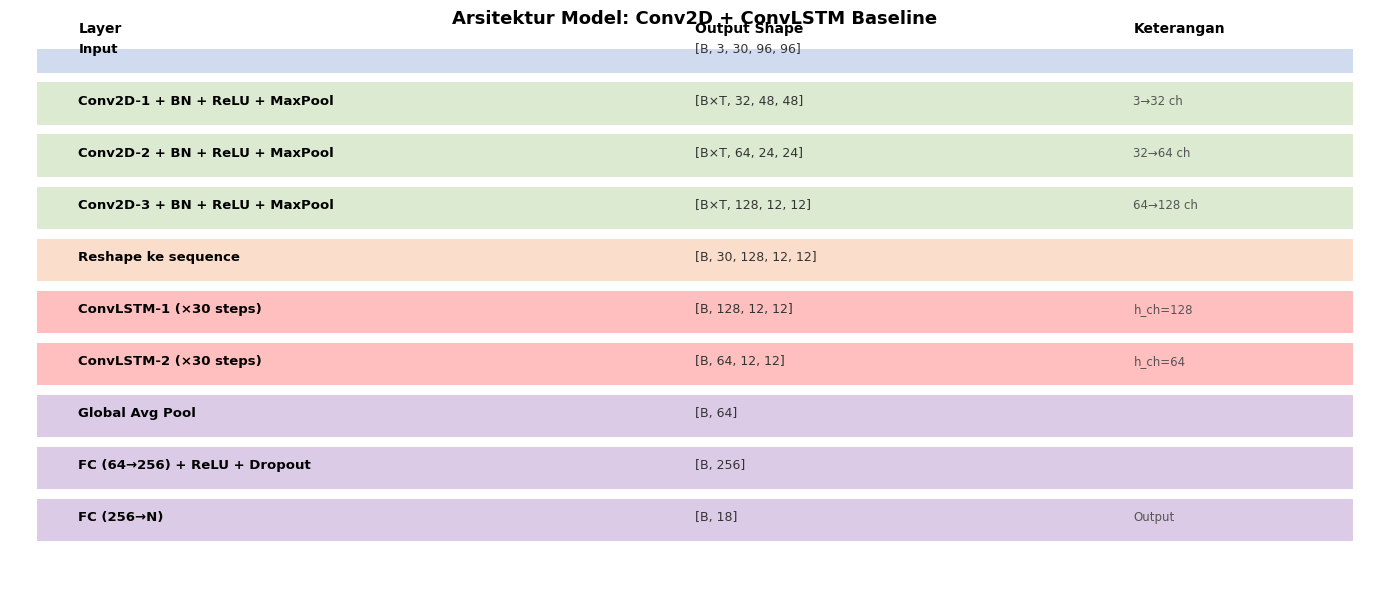

Saved: model_architecture.png


In [30]:
# ── Cell 9: Visualisasi arsitektur model ───────────────────────────────────
layers_info = [
    ('Input',             '[B, 3, 30, 96, 96]',  ''),
    ('Conv2D-1 + BN + ReLU + MaxPool', '[B×T, 32, 48, 48]', '3→32 ch'),
    ('Conv2D-2 + BN + ReLU + MaxPool', '[B×T, 64, 24, 24]', '32→64 ch'),
    ('Conv2D-3 + BN + ReLU + MaxPool', '[B×T, 128, 12, 12]', '64→128 ch'),
    ('Reshape ke sequence', '[B, 30, 128, 12, 12]', ''),
    ('ConvLSTM-1 (×30 steps)', '[B, 128, 12, 12]', 'h_ch=128'),
    ('ConvLSTM-2 (×30 steps)', '[B, 64, 12, 12]',  'h_ch=64'),
    ('Global Avg Pool',  '[B, 64]',               ''),
    ('FC (64→256) + ReLU + Dropout', '[B, 256]',  ''),
    ('FC (256→N)',        f'[B, {NUM_CLASSES}]',   'Output'),
]

fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')
colors = ['#4472C4'] + ['#70AD47'] * 3 + ['#ED7D31'] + ['#FF0000'] * 2 + ['#7030A0'] * 3
for i, (name, shape, note) in enumerate(layers_info):
    y = 1 - i * 0.098
    ax.add_patch(plt.Rectangle((0.02, y - 0.045), 0.96, 0.08,
                                facecolor=colors[i], alpha=0.25, transform=ax.transAxes))
    ax.text(0.05, y, name,      transform=ax.transAxes, va='center', fontsize=9.5, fontweight='bold')
    ax.text(0.50, y, shape,     transform=ax.transAxes, va='center', fontsize=9, color='#333')
    ax.text(0.82, y, note,      transform=ax.transAxes, va='center', fontsize=8.5, color='#555')

ax.text(0.05, 1.03, 'Layer',       transform=ax.transAxes, fontsize=10, fontweight='bold')
ax.text(0.50, 1.03, 'Output Shape',transform=ax.transAxes, fontsize=10, fontweight='bold')
ax.text(0.82, 1.03, 'Keterangan', transform=ax.transAxes, fontsize=10, fontweight='bold')
ax.set_title('Arsitektur Model: Conv2D + ConvLSTM Baseline', fontsize=13, fontweight='bold', pad=18)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model_architecture.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_architecture.png')

---
## Training

In [31]:
# ── Cell 10: Loss, optimizer, scheduler ─────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-6)

print('Loss      : CrossEntropyLoss')
print('Optimizer : Adam')
print('Scheduler : ReduceLROnPlateau (mode=max, factor=0.5, patience=5)')

Loss      : CrossEntropyLoss
Optimizer : Adam
Scheduler : ReduceLROnPlateau (mode=max, factor=0.5, patience=5)


In [32]:
# ── Cell 11: Fungsi train & eval ────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_sum, correct, total = 0., 0, 0
    for x, y in tqdm(loader, desc='Train', leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * x.size(0)
        correct  += (out.argmax(1) == y).sum().item()
        total    += y.size(0)
    return loss_sum / total, 100. * correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, correct, total = 0., 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in tqdm(loader, desc='Eval', leave=False):
            x, y = x.to(device), y.to(device)
            out  = model(x)
            loss = criterion(out, y)
            loss_sum += loss.item() * x.size(0)
            pred = out.argmax(1)
            correct  += (pred == y).sum().item()
            total    += y.size(0)
            all_preds.extend(pred.cpu().tolist())
            all_labels.extend(y.cpu().tolist())

    avg_loss = loss_sum / total
    accuracy = 100. * correct / total
    per_class = {}
    for ci in range(NUM_CLASSES):
        mask = [l == ci for l in all_labels]
        if any(mask):
            c = sum(p == ci for p, m in zip(all_preds, mask) if m)
            per_class[ci] = 100. * c / sum(mask)
        else:
            per_class[ci] = 0.
    return avg_loss, accuracy, per_class, all_preds, all_labels

In [33]:
# ── Cell 12: Training loop ──────────────────────────────────────────────────
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': [], 'epoch_time': []}

best_val_acc    = 0.
best_epoch      = 0
best_model_path = MODELS_DIR / 'baseline_gabungan_best.pth'

t_start = time.time()
print(f'Training {NUM_EPOCHS} epochs | {len(train_loader)} batches/epoch | {NUM_CLASSES} kelas\n')
print(f'{"Epoch":>6}  {"TrainLoss":>10} {"TrainAcc":>9} {"ValLoss":>9} {"ValAcc":>8}  {"LR":>8}  {"Time":>6}  {"Flag"}')
print('-' * 90)

for epoch in range(1, NUM_EPOCHS + 1):
    t_ep = time.time()

    tr_loss, tr_acc                = train_one_epoch(model, train_loader, criterion, optimizer, device)
    va_loss, va_acc, per_cls, _, _ = evaluate(model, val_loader, criterion, device)

    scheduler.step(va_acc)
    cur_lr     = optimizer.param_groups[0]['lr']
    epoch_time = time.time() - t_ep

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)
    history['lr'].append(cur_lr)
    history['epoch_time'].append(epoch_time)

    flag = ''
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_epoch   = epoch
        torch.save({
            'epoch'               : epoch,
            'model_state_dict'    : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc'             : va_acc,
            'val_loss'            : va_loss,
            'num_classes'         : NUM_CLASSES,
            'classes'             : CLASSES
        }, best_model_path)
        flag = '<-- best'

    print(f'{epoch:6d}  {tr_loss:10.4f} {tr_acc:9.2f}% {va_loss:9.4f} {va_acc:8.2f}%  {cur_lr:8.2e}  {epoch_time:5.0f}s  {flag}')

    # Per-class ringkas
    cls_str = '  '.join([f'{IDX_TO_CLASS[k]}:{v:.0f}%' for k, v in per_cls.items()])
    print(f'         per-class: {cls_str}')

    if torch.cuda.is_available() and epoch % 5 == 0:
        torch.cuda.empty_cache()

total_time = time.time() - t_start
print('\n' + '=' * 90)
print(f'Training selesai dalam {total_time/60:.1f} menit')
print(f'Best val acc: {best_val_acc:.2f}% di epoch {best_epoch}')
print(f'Model disimpan: {best_model_path}')

Training 100 epochs | 315 batches/epoch | 18 kelas

 Epoch   TrainLoss  TrainAcc   ValLoss   ValAcc        LR    Time  Flag
------------------------------------------------------------------------------------------


Train:   0%|          | 0/315 [00:00<?, ?it/s]

Eval:   0%|          | 0/90 [00:00<?, ?it/s]

     1      2.6749     10.83%    2.5522    15.14%  1.00e-03     58s  <-- best
         per-class: 1:8%  2:0%  3:0%  8:0%  9:2%  10:15%  a:12%  b:2%  c:0%  d:52%  e:0%  f:35%  buku:75%  dia:8%  saya:0%  keliling:60%  kelompok:0%  sekarang:2%


Train:   0%|          | 0/315 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/90 [00:00<?, ?it/s]

    99      0.0012    100.00%    0.7970    83.75%  1.00e-06     59s  
         per-class: 1:92%  2:95%  3:80%  8:92%  9:85%  10:95%  a:100%  b:92%  c:70%  d:78%  e:85%  f:82%  buku:98%  dia:52%  saya:70%  keliling:80%  kelompok:82%  sekarang:78%


Train:   0%|          | 0/315 [00:00<?, ?it/s]

Eval:   0%|          | 0/90 [00:00<?, ?it/s]

   100      0.0013    100.00%    0.7978    83.61%  1.00e-06     59s  
         per-class: 1:92%  2:95%  3:80%  8:92%  9:85%  10:98%  a:100%  b:92%  c:68%  d:72%  e:88%  f:85%  buku:98%  dia:52%  saya:70%  keliling:78%  kelompok:82%  sekarang:78%

Training selesai dalam 98.1 menit
Best val acc: 84.58% di epoch 48
Model disimpan: /home/wipra-ranum/Documents/Skripsi/LipReading/Lip_Reading_Gabungan/models/baseline_gabungan_best.pth


---
## Kurva Training

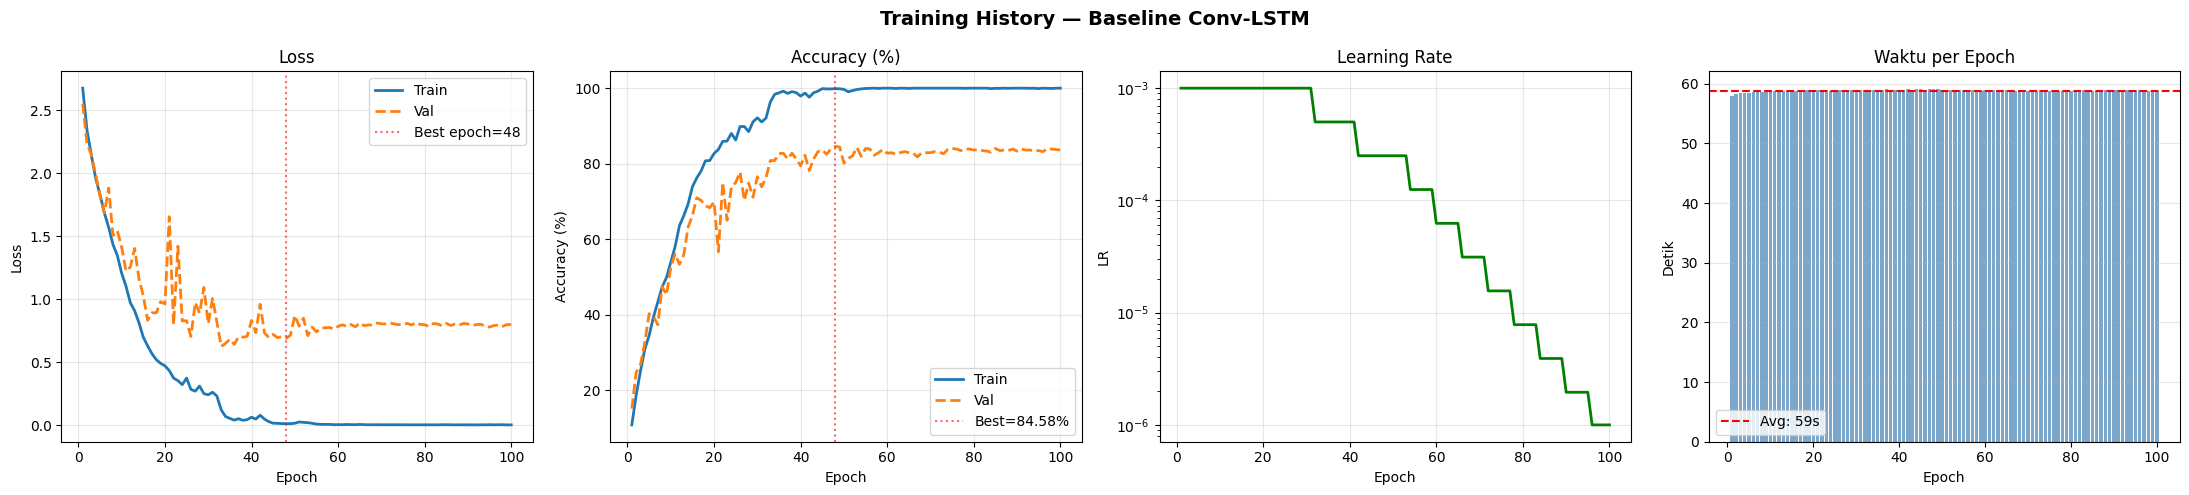

Saved: training_curves.png


In [34]:
# ── Cell 13: Training curves ────────────────────────────────────────────────
ep_ran   = len(history['train_loss'])
ep_range = range(1, ep_ran + 1)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Training History — Baseline Conv-LSTM', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(ep_range, history['train_loss'], label='Train', linewidth=2)
axes[0].plot(ep_range, history['val_loss'],   label='Val',   linewidth=2, linestyle='--')
axes[0].axvline(best_epoch, color='red', linestyle=':', alpha=0.6, label=f'Best epoch={best_epoch}')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(ep_range, history['train_acc'], label='Train', linewidth=2)
axes[1].plot(ep_range, history['val_acc'],   label='Val',   linewidth=2, linestyle='--')
axes[1].axvline(best_epoch, color='red', linestyle=':', alpha=0.6, label=f'Best={best_val_acc:.2f}%')
axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Learning Rate
axes[2].plot(ep_range, history['lr'], linewidth=2, color='green')
axes[2].set_title('Learning Rate'); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
axes[2].set_yscale('log'); axes[2].grid(alpha=0.3)

# Epoch time
axes[3].bar(ep_range, history['epoch_time'], color='steelblue', alpha=0.7)
axes[3].axhline(np.mean(history['epoch_time']), color='red', linestyle='--',
                label=f'Avg: {np.mean(history["epoch_time"]):.0f}s')
axes[3].set_title('Waktu per Epoch'); axes[3].set_xlabel('Epoch'); axes[3].set_ylabel('Detik')
axes[3].legend(); axes[3].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

---
## Evaluasi Test Set

In [35]:
# ── Cell 14: Load best model & test ────────────────────────────────────────
ckpt = torch.load(best_model_path, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded best model epoch {ckpt["epoch"]} (val acc: {ckpt["val_acc"]:.2f}%)')

test_loss, test_acc, test_per_cls, test_preds, test_labels = evaluate(
    model, test_loader, criterion, device
)

# Hitung semua metrik
f1_macro   = f1_score(test_labels, test_preds, average='macro')   * 100
f1_weight  = f1_score(test_labels, test_preds, average='weighted')* 100
prec_macro = precision_score(test_labels, test_preds, average='macro',   zero_division=0) * 100
rec_macro  = recall_score(test_labels,   test_preds, average='macro',    zero_division=0) * 100
prec_w     = precision_score(test_labels, test_preds, average='weighted', zero_division=0) * 100
rec_w      = recall_score(test_labels,   test_preds, average='weighted',  zero_division=0) * 100

print('\n' + '=' * 55)
print('  HASIL EVALUASI TEST SET')
print('=' * 55)
print(f'  Test Loss             : {test_loss:.4f}')
print(f'  Test Accuracy         : {test_acc:.2f}%')
print(f'  Precision (macro)     : {prec_macro:.2f}%')
print(f'  Precision (weighted)  : {prec_w:.2f}%')
print(f'  Recall    (macro)     : {rec_macro:.2f}%')
print(f'  Recall    (weighted)  : {rec_w:.2f}%')
print(f'  F1-score  (macro)     : {f1_macro:.2f}%')
print(f'  F1-score  (weighted)  : {f1_weight:.2f}%')
print('=' * 55)

Loaded best model epoch 48 (val acc: 84.58%)


Eval:   0%|          | 0/45 [00:00<?, ?it/s]


  HASIL EVALUASI TEST SET
  Test Loss             : 0.8074
  Test Accuracy         : 83.06%
  Precision (macro)     : 83.41%
  Precision (weighted)  : 83.41%
  Recall    (macro)     : 83.06%
  Recall    (weighted)  : 83.06%
  F1-score  (macro)     : 82.96%
  F1-score  (weighted)  : 82.96%


In [36]:
# ── Cell 15: Classification report ─────────────────────────────────────────
print('Classification Report per Kelas:\n')
print(classification_report(test_labels, test_preds, target_names=CLASSES, digits=3))

Classification Report per Kelas:

              precision    recall  f1-score   support

           1      0.947     0.900     0.923        20
           2      0.947     0.900     0.923        20
           3      0.800     0.800     0.800        20
           8      0.905     0.950     0.927        20
           9      0.900     0.900     0.900        20
          10      0.909     1.000     0.952        20
           a      1.000     1.000     1.000        20
           b      0.950     0.950     0.950        20
           c      0.800     0.600     0.686        20
           d      0.615     0.800     0.696        20
           e      0.944     0.850     0.895        20
           f      0.833     1.000     0.909        20
        buku      0.818     0.900     0.857        20
         dia      0.778     0.700     0.737        20
        saya      0.571     0.600     0.585        20
    keliling      0.684     0.650     0.667        20
    kelompok      0.833     0.750     0.789    

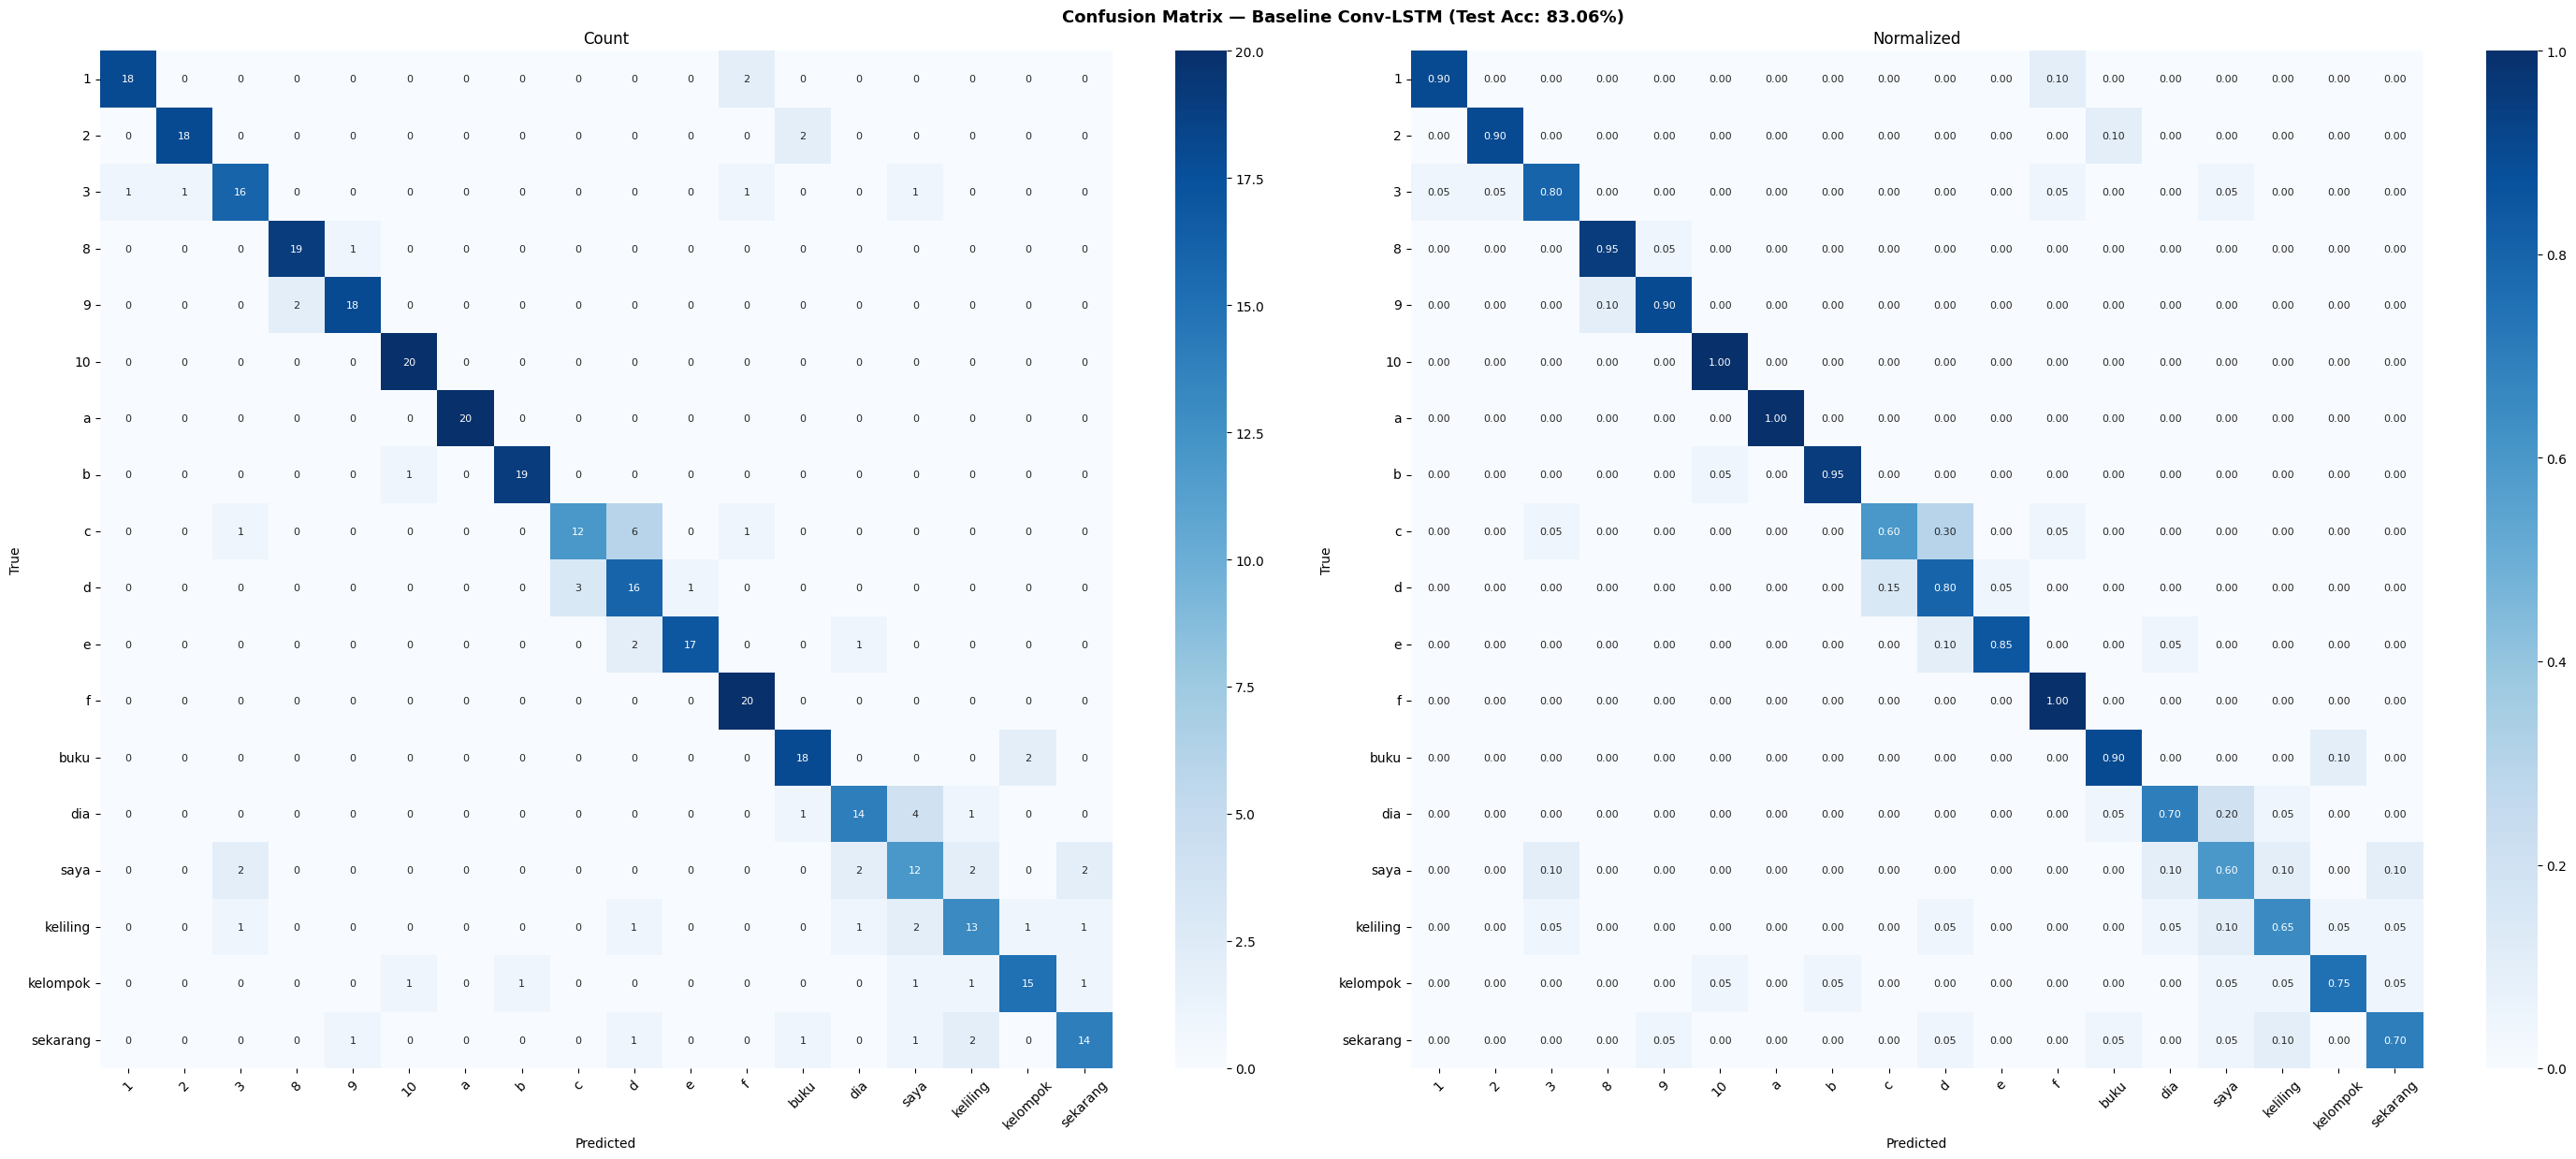

Saved: confusion_matrix.png


In [37]:
# ── Cell 16: Confusion matrix ───────────────────────────────────────────────
cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig_w = max(14, NUM_CLASSES * 0.8)
fig_h = max(10, NUM_CLASSES * 0.7)
fig, axes = plt.subplots(1, 2, figsize=(fig_w * 2, fig_h))
fig.suptitle(f'Confusion Matrix — Baseline Conv-LSTM (Test Acc: {test_acc:.2f}%)',
             fontsize=13, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=CLASSES, yticklabels=CLASSES, annot_kws={'size': 8})
axes[0].set_title('Count'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=CLASSES, yticklabels=CLASSES, annot_kws={'size': 8},
            vmin=0, vmax=1)
axes[1].set_title('Normalized'); axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

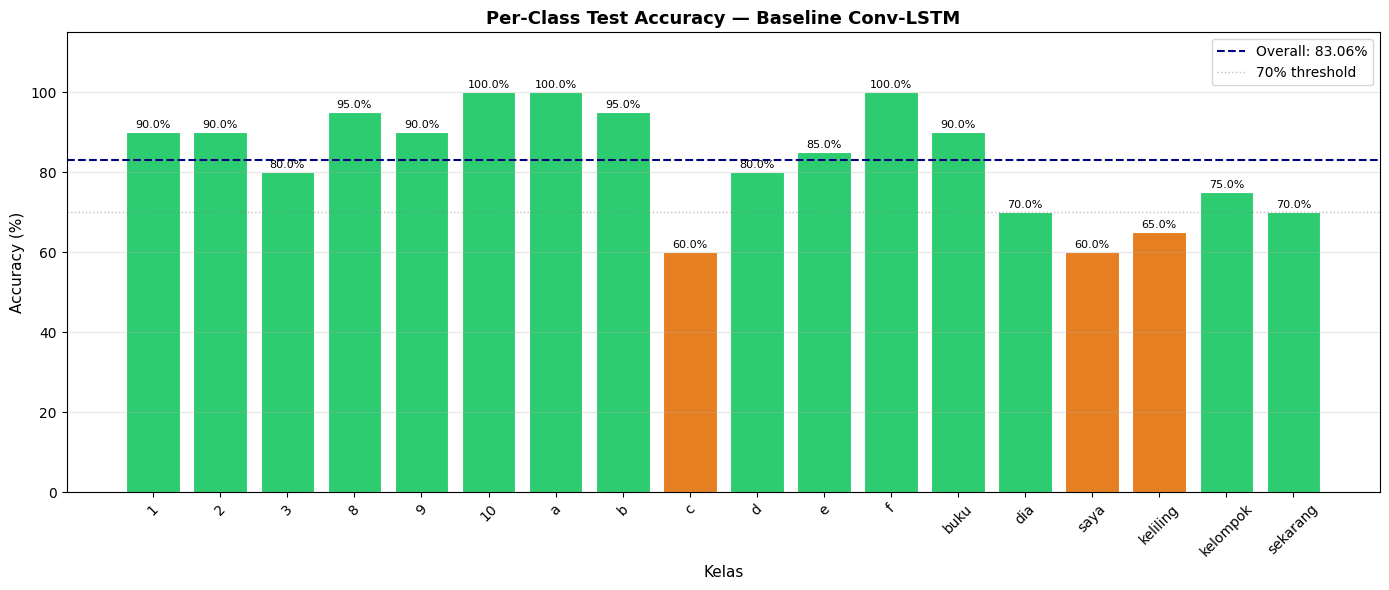

Saved: per_class_accuracy.png


In [38]:
# ── Cell 17: Per-class accuracy bar chart ───────────────────────────────────
class_accs = [test_per_cls[i] for i in range(NUM_CLASSES)]

colors_bar = ['#2ecc71' if a >= 70 else '#e67e22' if a >= 40 else '#e74c3c' for a in class_accs]

fig, ax = plt.subplots(figsize=(max(14, NUM_CLASSES * 0.7), 6))
bars = ax.bar(CLASSES, class_accs, color=colors_bar, edgecolor='white', linewidth=0.8)
for bar, acc in zip(bars, class_accs):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=8)
ax.axhline(test_acc, color='navy', linestyle='--', linewidth=1.5, label=f'Overall: {test_acc:.2f}%')
ax.axhline(70, color='gray', linestyle=':', linewidth=1, alpha=0.5, label='70% threshold')
ax.set_xlabel('Kelas', fontsize=11); ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Per-Class Test Accuracy — Baseline Conv-LSTM', fontsize=13, fontweight='bold')
ax.set_ylim([0, 115]); ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: per_class_accuracy.png')

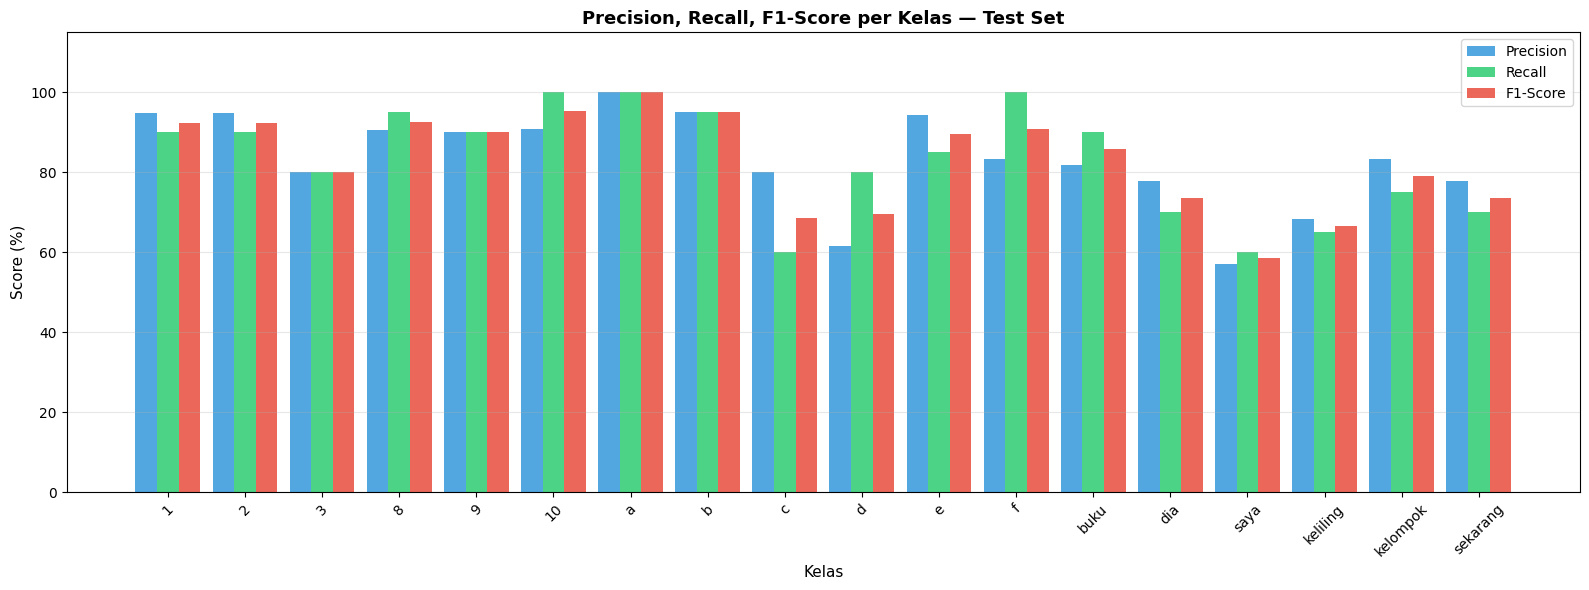

Saved: precision_recall_f1.png


In [39]:
# ── Cell 18: Precision, Recall, F1 per kelas (bar grouped) ──────────────────
report_dict = classification_report(
    test_labels, test_preds, target_names=CLASSES, output_dict=True, zero_division=0
)

prec_per  = [report_dict[c]['precision'] * 100 for c in CLASSES]
rec_per   = [report_dict[c]['recall']    * 100 for c in CLASSES]
f1_per    = [report_dict[c]['f1-score']  * 100 for c in CLASSES]

x_pos = np.arange(NUM_CLASSES)
width = 0.28

fig, ax = plt.subplots(figsize=(max(16, NUM_CLASSES * 0.8), 6))
ax.bar(x_pos - width, prec_per, width, label='Precision', color='#3498db', alpha=0.85)
ax.bar(x_pos,         rec_per,  width, label='Recall',    color='#2ecc71', alpha=0.85)
ax.bar(x_pos + width, f1_per,   width, label='F1-Score',  color='#e74c3c', alpha=0.85)
ax.set_xticks(x_pos); ax.set_xticklabels(CLASSES, rotation=45)
ax.set_xlabel('Kelas', fontsize=11); ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title('Precision, Recall, F1-Score per Kelas — Test Set', fontsize=13, fontweight='bold')
ax.set_ylim([0, 115]); ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'precision_recall_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: precision_recall_f1.png')

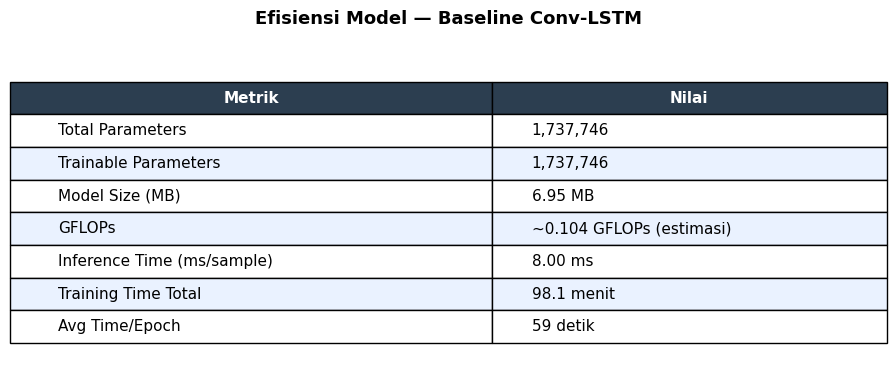

Saved: model_efficiency.png


In [40]:
# ── Cell 19: Ringkasan efisiensi model (tabel visual) ───────────────────────
efficiency_data = {
    'Metrik'  : ['Total Parameters', 'Trainable Parameters', 'Model Size (MB)',
                  'GFLOPs', 'Inference Time (ms/sample)',
                  'Training Time Total', 'Avg Time/Epoch'],
    'Nilai'   : [
        f'{total_params:,}',
        f'{trainable_params:,}',
        f'{model_size_mb:.2f} MB',
        gflops_str,
        f'{infer_ms:.2f} ms',
        f'{total_time/60:.1f} menit',
        f'{np.mean(history["epoch_time"]):.0f} detik'
    ]
}

fig, ax = plt.subplots(figsize=(9, 4))
ax.axis('off')
df_eff = pd.DataFrame(efficiency_data)
tbl = ax.table(cellText=df_eff.values, colLabels=df_eff.columns,
               cellLoc='left', loc='center', colWidths=[0.55, 0.45])
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 1.8)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#EAF2FF')
ax.set_title('Efisiensi Model — Baseline Conv-LSTM', fontsize=13,
             fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_efficiency.png')

---
## Simpan Semua Hasil

In [41]:
# ── Cell 20: Save summary JSON + CSV ───────────────────────────────────────
summary = {
    'model'    : 'Baseline Conv2D + ConvLSTM (RGB only)',
    'dataset'  : 'SIBI Dependent Gabungan',
    'model_info': {
        'total_params'    : total_params,
        'trainable_params': trainable_params,
        'model_size_mb'   : round(model_size_mb, 2),
        'gflops'          : gflops_str,
        'inference_ms'    : round(infer_ms, 2)
    },
    'training' : {
        'epochs_trained'      : ep_ran,
        'best_epoch'          : best_epoch,
        'batch_size'          : BATCH_SIZE,
        'learning_rate'       : LR,
        'weight_decay'        : WEIGHT_DECAY,
        'optimizer'           : 'Adam',
        'scheduler'           : 'ReduceLROnPlateau (max, factor=0.5, patience=5)',
        'best_val_acc'        : round(best_val_acc, 4),
        'total_time_minutes'  : round(total_time / 60, 2),
        'avg_epoch_time_sec'  : round(np.mean(history['epoch_time']), 1)
    },
    'test_results': {
        'test_loss'       : round(test_loss, 4),
        'accuracy'        : round(test_acc, 4),
        'precision_macro' : round(prec_macro, 4),
        'precision_weighted': round(prec_w, 4),
        'recall_macro'    : round(rec_macro, 4),
        'recall_weighted' : round(rec_w, 4),
        'f1_macro'        : round(f1_macro, 4),
        'f1_weighted'     : round(f1_weight, 4),
        'per_class_acc'   : {CLASSES[i]: round(acc, 2) for i, acc in enumerate(class_accs)}
    }
}

with open(RESULTS_DIR / 'baseline_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

# Training history CSV
pd.DataFrame({
    'epoch'      : range(1, ep_ran + 1),
    'train_loss' : history['train_loss'],
    'train_acc'  : history['train_acc'],
    'val_loss'   : history['val_loss'],
    'val_acc'    : history['val_acc'],
    'lr'         : history['lr'],
    'epoch_time' : history['epoch_time']
}).to_csv(RESULTS_DIR / 'training_history.csv', index=False)

# Classification report CSV
report_rows = []
for cls in CLASSES:
    r = report_dict[cls]
    report_rows.append({'class': cls, 'precision': round(r['precision']*100,2),
                        'recall': round(r['recall']*100,2), 'f1': round(r['f1-score']*100,2),
                        'support': int(r['support'])})
pd.DataFrame(report_rows).to_csv(RESULTS_DIR / 'classification_report.csv', index=False)

print('Files saved:')
all_files = [
    ('models', 'baseline_gabungan_best.pth'),
    ('results', 'baseline_summary.json'),
    ('results', 'training_history.csv'),
    ('results', 'classification_report.csv'),
    ('results', 'model_architecture.png'),
    ('results', 'training_curves.png'),
    ('results', 'confusion_matrix.png'),
    ('results', 'per_class_accuracy.png'),
    ('results', 'precision_recall_f1.png'),
    ('results', 'model_efficiency.png'),
]
for kind, fname in all_files:
    path = (MODELS_DIR if kind == 'models' else RESULTS_DIR) / fname
    print(f'  [{"✓" if path.exists() else "✗"}] {fname}')

print(f'\nBaseline training selesai!')
print(f'Test Accuracy  : {test_acc:.2f}%')
print(f'F1 (weighted)  : {f1_weight:.2f}%')
print(f'Best epoch     : {best_epoch}/{ep_ran}')

Files saved:
  [✓] baseline_gabungan_best.pth
  [✓] baseline_summary.json
  [✓] training_history.csv
  [✓] classification_report.csv
  [✓] model_architecture.png
  [✓] training_curves.png
  [✓] confusion_matrix.png
  [✓] per_class_accuracy.png
  [✓] precision_recall_f1.png
  [✓] model_efficiency.png

Baseline training selesai!
Test Accuracy  : 83.06%
F1 (weighted)  : 82.96%
Best epoch     : 48/100
